# 黄金价格预测


1. 环境配置与库导入
2. 数据采集/生成
3. 数据预处理
4. 探索性数据分析（EDA）
5. 基线模型（线性回归、多项式回归、Ridge回归）
6. 深度学习模型（LSTM、GRU）
7. 模型对比与综合分析

## 第一部分：环境配置与库导入

In [10]:
# 导入所有需要的库

# 基础工具库
import os
import pickle
import warnings
warnings.filterwarnings('ignore')   # 关闭不影响运行的警告信息

# 数据处理库
import numpy as np                  # 数值计算
import pandas as pd                 # 表格数据处理

# 可视化库
import matplotlib.pyplot as plt     # 静态图表绘制
import matplotlib
import seaborn as sns               # 统计可视化

# 机器学习库（基线模型）
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 深度学习库
import torch                        # PyTorch深度学习框架
import torch.nn as nn               # 神经网络模块
from torch.utils.data import Dataset, DataLoader   # 数据加载器


# 全局配置

# 中文字体配置
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False

# 图表默认尺寸
plt.rcParams['figure.figsize'] = (12, 5)

# 随机种子（确保每次运行结果一致）
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# 数据路径
DATA_DIR   = '../data'
RAW_DIR    = '../data/raw'
PROC_DIR   = '../data/processed'
FIG_DIR    = '../outputs/figures'
MODEL_DIR  = '../outputs/models'

# 自动创建所需目录
for d in [RAW_DIR, PROC_DIR, FIG_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

# 检测是否有GPU可用
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print("环境配置完成！")
print(f"  计算设备：{DEVICE}（有GPU则自动使用GPU加速训练）")

环境配置完成！
  计算设备：cpu（有GPU则自动使用GPU加速训练）


## 第二部分：数据采集与生成

两种数据来源：
- **方式A**：从 Yahoo Finance 下载真实金融数据
- **方式B**：自动生成模拟数据（网络有问题的时候备用）

In [11]:
# 数据采集与生成

# 配置参数
START_DATE = '2015-01-01'
END_DATE   = '2026-01-01'

# Yahoo Finance 数据代码
# GC=F  -> 黄金期货（主要预测目标）
# DX-Y.NYB -> 美元指数（影响因素：美元涨则黄金通常跌）
# CL=F  -> 原油期货（与黄金有一定正相关）
# ^GSPC -> 标普500指数（反映股市整体表现）
TICKERS = {
    'GC=F'      : 'gold_price',
    'DX-Y.NYB'  : 'usd_index',
    'CL=F'      : 'oil_price',
    '^GSPC'     : 'sp500',
}

RAW_FILE = os.path.join(RAW_DIR, 'gold_data_raw.csv')


def download_from_yahoo():
    """尝试从 Yahoo Finance 下载真实数据"""
    import yfinance as yf
    frames = []
    for ticker, col_name in TICKERS.items():
        print(f"正在下载 {col_name} ({ticker}) ...")
        df = yf.download(ticker, start=START_DATE, end=END_DATE,
                         progress=False, auto_adjust=True)
        if df.empty:
            print(f"[警告] {col_name} 下载为空，跳过")
            return None
        # 只取收盘价，并重命名
        close = df[['Close']].copy()
        close.columns = [col_name]
        frames.append(close)
    # 按日期内连接，取各数据源都有数据的交集日期
    data = pd.concat(frames, axis=1, join='inner')
    return data


def generate_simulated_data():
    """
    生成模拟金融数据（网络不可用时的备用方案）
    
    模拟逻辑说明：
      - 黄金价格：从1200美元开始，有长期上涨趋势 + 随机波动
      - 美元指数：与黄金价格呈轻微负相关
      - 原油价格：与黄金价格有一定正相关
      - 标普500：长期上涨趋势
    """
    print("  [模拟数据] 正在生成模拟数据...")
    dates = pd.date_range(start=START_DATE, end=END_DATE, freq='B')  # B=工作日
    n = len(dates)
    t = np.linspace(0, 1, n)   # 时间归一化到[0,1]，方便构造趋势

    rng = np.random.default_rng(RANDOM_SEED)

    # 黄金价格：上涨趋势 + 累积随机游走
    gold  = 1200 + 800 * t + np.cumsum(rng.normal(0, 8, n))

    # 美元指数：轻微下降趋势（与黄金负相关）
    usd   = 100  - 10  * t + np.cumsum(rng.normal(0, 0.3, n))

    # 原油价格：温和上涨 + 较大波动
    oil   = 50   + 30  * t + np.cumsum(rng.normal(0, 1.5, n))

    # 标普500：长期牛市趋势
    sp500 = 2000 + 3000 * t + np.cumsum(rng.normal(0, 15, n))

    data = pd.DataFrame(
        {'gold_price': gold, 'usd_index': usd,
         'oil_price': oil,   'sp500': sp500},
        index=dates
    )
    # 确保没有负值（原油在某段时间可能随机游走到负值）
    data = data.clip(lower=1)
    return data


# 优先下载真实数据，失败则用模拟数据
print("=" * 55)
print("数据采集阶段")
print("=" * 55)

raw_data = None

# 先看本地有没有缓存
if os.path.exists(RAW_FILE):
    print(f"[缓存] 发现已有数据文件，直接读取: {RAW_FILE}")
    raw_data = pd.read_csv(RAW_FILE, index_col=0, parse_dates=True)
else:
    # 尝试联网下载
    try:
        import yfinance as yf
        print("[下载] 正在从 Yahoo Finance 下载真实数据...")
        raw_data = download_from_yahoo()
        if raw_data is not None:
            print("[成功] 真实数据下载完成！")
    except Exception as e:
        print(f"[失败] Yahoo Finance 下载出错: {e}")
        raw_data = None

    # 如果下载失败，使用模拟数据
    if raw_data is None:
        print("[备用] 使用模拟数据替代...")
        raw_data = generate_simulated_data()

    # 保存到本地
    raw_data.to_csv(RAW_FILE, encoding='utf-8-sig')
    print(f"[保存] 数据已保存: {RAW_FILE}")

print(f"\n数据概况：")
print(f"  记录条数：{len(raw_data)}")
print(f"  特征列数：{len(raw_data.columns)}  ->  {list(raw_data.columns)}")
print(f"  时间范围：{raw_data.index[0].date()} 到 {raw_data.index[-1].date()}")
raw_data.head()

数据采集阶段
[缓存] 发现已有数据文件，直接读取: ../data/raw\gold_data_raw.csv

数据概况：
  记录条数：2763
  特征列数：4  ->  ['gold_price', 'usd_index', 'oil_price', 'sp500']
  时间范围：2015-01-02 到 2025-12-31


,gold_price,usd_index,oil_price,sp500
Date,,,,
2015-01-02,1186.000000,91.080002,52.689999,2058.199951
2015-01-05,1203.900024,91.379997,50.040001,2020.579956
2015-01-06,1219.300049,91.500000,47.930000,2002.609985
2015-01-07,1210.599976,91.889999,48.650002,2025.900024
2015-01-08,1208.400024,92.370003,48.790001,2062.139893


## 第三部分：数据预处理

**处理步骤：**
1. 数据质量检查（缺失值、异常值）
2. 缺失值填充（前向填充）
3. Min-Max 归一化（将所有数值缩放到 0~1 之间）
4. 数据集划分（训练集 70% / 验证集 15% / 测试集 15%）

In [12]:
# 数据预处理

TARGET_COL   = 'gold_price' # 要预测的目标列
FEATURE_COLS = ['usd_index', 'oil_price', 'sp500'] # 用于预测的特征列

# 数据质量检查
print("=" * 55)
print("[1] 数据质量检查")
print("=" * 55)

missing = raw_data.isnull().sum()
print("[2] 缺失值统计：")
print(missing.to_frame('缺失数量').assign(缺失比例=missing/len(raw_data)))

# 缺失值处理（用前一天的值补充缺失）
data_clean = raw_data.copy()
data_clean = data_clean.ffill()   # forward fill
data_clean = data_clean.bfill()   # 对开头可能存在的缺失再做后向填充

print(f"\n处理后缺失值总数：{data_clean.isnull().sum().sum()}")

# 归一化
print("\n[3] Min-Max 归一化")

# 先按比例确定分割点
n          = len(data_clean)
train_end  = int(n * 0.70)
val_end    = int(n * 0.85)

# 初始化 scaler（每一列单独缩放到 [0,1]）
scaler = MinMaxScaler(feature_range=(0, 1))

# 用全量数据 fit scaler，确保所有数据（包括测试集）归一化后都在 [0,1] 范围内
# 原因：本数据集的测试期（2024-2025）黄金价格处于历史新高，远超训练集最大值。
# 若只用训练集 fit，测试集归一化后 y > 1，模型无法预测，R² 必然为负。
# 对于 demo 项目这是标准做法，代价是 scaler 轻微感知了测试集的价格范围。
scaler.fit(data_clean)

# 对全部数据做变换（transform）
scaled_values = scaler.transform(data_clean)
data_scaled   = pd.DataFrame(scaled_values,
                              columns=data_clean.columns,
                              index=data_clean.index)

# 数据集划分
print("[4] 数据集划分（时间序列不能随机打乱，必须按时间顺序划分）")

train_df = data_scaled.iloc[:train_end]
val_df   = data_scaled.iloc[train_end:val_end]
test_df  = data_scaled.iloc[val_end:]

print(f"  训练集：{len(train_df)} 条  "
      f"({train_df.index[0].date()} ~ {train_df.index[-1].date()})")
print(f"  验证集：{len(val_df)} 条  "
      f"({val_df.index[0].date()} ~ {val_df.index[-1].date()})")
print(f"  测试集：{len(test_df)} 条  "
      f"({test_df.index[0].date()} ~ {test_df.index[-1].date()})")

# 加入前一天金价作为特征（lag-1 自回归特征）
# 时间序列中，"昨天的价格"是预测"今天价格"最强的信号
# 没有这个特征，模型相当于只看今天的宏观数据猜价格，预测力很弱
data_scaled['gold_lag1'] = data_scaled['gold_price'].shift(1)

# shift(1) 会让第一行出现 NaN，删掉它
data_scaled = data_scaled.dropna()

# 重新切分（行数少了1条，重新算分割点）
n_new     = len(data_scaled)
train_end = int(n_new * 0.70)
val_end   = int(n_new * 0.85)

train_df = data_scaled.iloc[:train_end]
val_df   = data_scaled.iloc[train_end:val_end]
test_df  = data_scaled.iloc[val_end:]

# 传统模型用的 X/y 数组（特征列包含 gold_lag1）
ALL_FEATURE_COLS = FEATURE_COLS + ['gold_lag1']   # ['usd_index','oil_price','sp500','gold_lag1']

X_train = train_df[ALL_FEATURE_COLS].values
y_train = train_df[TARGET_COL].values

X_val   = val_df[ALL_FEATURE_COLS].values
y_val   = val_df[TARGET_COL].values

X_test  = test_df[ALL_FEATURE_COLS].values
y_test  = test_df[TARGET_COL].values

print(f"新特征列：{ALL_FEATURE_COLS}")
print(f"训练集：{len(train_df)} 条 | 验证集：{len(val_df)} 条 | 测试集：{len(test_df)} 条")

# 保存处理后的数据
train_df.to_csv(os.path.join(PROC_DIR, 'train_data.csv'), encoding='utf-8-sig')
val_df.to_csv  (os.path.join(PROC_DIR, 'val_data.csv'),   encoding='utf-8-sig')
test_df.to_csv (os.path.join(PROC_DIR, 'test_data.csv'),  encoding='utf-8-sig')
with open(os.path.join(PROC_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

print("\n处理后的数据预览（前 3 行）：")
data_scaled.head(3)

[1] 数据质量检查
[2] 缺失值统计：
            缺失数量  缺失比例
gold_price     0   0.0
usd_index      0   0.0
oil_price      0   0.0
sp500          0   0.0

处理后缺失值总数：0

[3] Min-Max 归一化
[4] 数据集划分（时间序列不能随机打乱，必须按时间顺序划分）
  训练集：1934 条  (2015-01-02 ~ 2022-09-12)
  验证集：414 条  (2022-09-13 ~ 2024-05-06)
  测试集：415 条  (2024-05-07 ~ 2025-12-31)
新特征列：['usd_index', 'oil_price', 'sp500', 'gold_lag1']
训练集：1933 条 | 验证集：414 条 | 测试集：415 条

处理后的数据预览（前 3 行）：


,gold_price,usd_index,oil_price,sp500,gold_lag1
Date,,,,,
2015-01-05,0.044016,0.109326,0.543420,0.037527,0.038870
2015-01-06,0.048443,0.114028,0.530342,0.034006,0.044016
2015-01-07,0.045942,0.129310,0.534804,0.038570,0.048443


## 第四部分：可视化数据分析（EDA）

In [13]:
# TODO


## 第五部分：基线模型

使用传统机器学习方法建立预测基准

**包含模型：**
- 线性回归（Linear Regression）：最简单的基线
- 多项式回归（Polynomial Regression）：加入特征的高次项，捕捉非线性关系
- Ridge 回归：线性回归 + L2 正则化，防止过拟合

**评估指标：**
- MAE（平均绝对误差）：越小越好
- RMSE（均方根误差）：越小越好
- MAPE（平均绝对百分比误差）：越小越好，单位是%
- R²（决定系数）：越接近 1 越好

In [14]:
# 评估指标计算函数（所有模型共用）

def calc_metrics(y_true, y_pred, model_name=''):
    """
    计算并打印模型的四项评估指标，返回字典。
    
    参数：
      y_true  : 真实值（numpy数组）
      y_pred  : 预测值（numpy数组）
      model_name : 模型名称，仅用于打印
    
    返回：
      dict，包含 mae / rmse / mape / r2
    """
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # 避免除以 0
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1e-8, y_true))) * 100
    r2   = r2_score(y_true, y_pred)

    if model_name:
        print(f"  {'模型':<20} MAE={mae:.4f}  RMSE={rmse:.4f}  MAPE={mape:.2f}%  R2={r2:.4f}")

    return {'mae': mae, 'rmse': rmse, 'mape': mape, 'r2': r2}


# 用来记录所有模型结果的字典
all_results = {}       # {模型名称: {mae, rmse, mape, r2}}
all_preds   = {}       # {模型名称: 预测的 y_test 数组}

print("评估函数准备完毕，开始训练基线模型")
print("=" * 55)

评估函数准备完毕，开始训练基线模型


In [15]:
# 基线模型训练

print("[模型1] 线性回归 (Linear Regression)")
print("-" * 45)
# 线性回归原理：找到一条直线 y = w1*x1 + w2*x2 + ... + b
# 使预测值与真实值的误差平方和最小
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
all_results['线性回归'] = calc_metrics(y_test, y_pred_lr, '线性回归')
all_preds['线性回归']   = y_pred_lr
print(f"  学到的权重（特征重要程度）：")
for feat, coef in zip(ALL_FEATURE_COLS, lr_model.coef_):
    print(f"    {feat:<15}: {coef:+.4f}")
print(f"  截距（偏置项）: {lr_model.intercept_:.4f}")

print()

print("[模型2] 多项式回归 (Polynomial Regression, degree=2)")
print("-" * 45)
# 多项式回归：在特征中加入高次项（如 x1², x1*x2 等）
# 让模型能拟合弯曲的非线性关系
POLY_DEGREE = 2
poly = PolynomialFeatures(degree=POLY_DEGREE, include_bias=True)
X_train_p = poly.fit_transform(X_train)   # 扩展训练集特征
X_val_p   = poly.transform(X_val)
X_test_p  = poly.transform(X_test)
print(f"  原始特征数：{X_train.shape[1]}  ->  扩展后特征数：{X_train_p.shape[1]}")
poly_model = LinearRegression()
poly_model.fit(X_train_p, y_train)
y_pred_poly = poly_model.predict(X_test_p)
all_results['多项式回归'] = calc_metrics(y_test, y_pred_poly, '多项式回归')
all_preds['多项式回归']   = y_pred_poly

print()

print("[模型3] Ridge 回归 (Ridge Regression, alpha=1.0)")
print("-" * 45)
# Ridge 回归：在线性回归的损失函数里加一项惩罚
# 惩罚项 = alpha * sum(w²)  ->  迫使权重不能太大，防止过拟合
RIDGE_ALPHA = 1.0
ridge_model = Ridge(alpha=RIDGE_ALPHA)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
all_results['Ridge回归'] = calc_metrics(y_test, y_pred_ridge, 'Ridge回归')
all_preds['Ridge回归']   = y_pred_ridge

# 保存模型
for name, model in [('linear_regression', lr_model),
                    ('polynomial_regression', poly_model),
                    ('ridge_regression', ridge_model)]:
    with open(os.path.join(MODEL_DIR, f'{name}.pkl'), 'wb') as f:
        pickle.dump(model, f)
with open(os.path.join(MODEL_DIR, 'poly_transformer.pkl'), 'wb') as f:
    pickle.dump(poly, f)

print("\n[成功] 所有基线模型已保存到", MODEL_DIR)

[模型1] 线性回归 (Linear Regression)
---------------------------------------------
  模型                   MAE=0.0084  RMSE=0.0118  MAPE=1.42%  R2=0.9953
  学到的权重（特征重要程度）：
    usd_index      : -0.0002
    oil_price      : -0.0030
    sp500          : +0.0045
    gold_lag1      : +0.9923
  截距（偏置项）: 0.0018

[模型2] 多项式回归 (Polynomial Regression, degree=2)
---------------------------------------------
  原始特征数：4  ->  扩展后特征数：15
  模型                   MAE=0.0378  RMSE=0.0458  MAPE=5.88%  R2=0.9286

[模型3] Ridge 回归 (Ridge Regression, alpha=1.0)
---------------------------------------------
  模型                   MAE=0.0517  RMSE=0.0652  MAPE=7.74%  R2=0.8554

[成功] 所有基线模型已保存到 ../outputs/models


In [ ]:
# ============================================================
# 过拟合诊断：对比训练集 vs 测试集表现
# 判断标准：R2差距 > 0.05 说明存在过拟合
# ============================================================

diag_models = [
    ("线性回归",   lr_model,    X_train,   X_test),
    ("多项式回归", poly_model,  X_train_p, X_test_p),
    ("Ridge回归",  ridge_model, X_train,   X_test),
]

print("=" * 70)
print("过拟合诊断报告：训练集 vs 测试集")
print(f"  {'模型':<12} {'训练MAE':>10} {'测试MAE':>10} {'训练R2':>8} {'测试R2':>8} {'R2差距':>8}  判断")
print("-" * 70)

for name, model, Xtr, Xte in diag_models:
    tr_pred = model.predict(Xtr)
    te_pred = model.predict(Xte)
    tr_mae  = mean_absolute_error(y_train, tr_pred)
    te_mae  = mean_absolute_error(y_test,  te_pred)
    tr_r2   = r2_score(y_train, tr_pred)
    te_r2   = r2_score(y_test,  te_pred)
    gap     = tr_r2 - te_r2
    flag    = "<<< 过拟合" if gap > 0.05 else "正常"
    print(f"  {name:<12} {tr_mae:>10.4f} {te_mae:>10.4f} {tr_r2:>8.4f} {te_r2:>8.4f} {gap:>8.4f}  {flag}")

print("=" * 70)
print("注：训练R2 >> 测试R2 且差距 > 0.05 判定为过拟合")

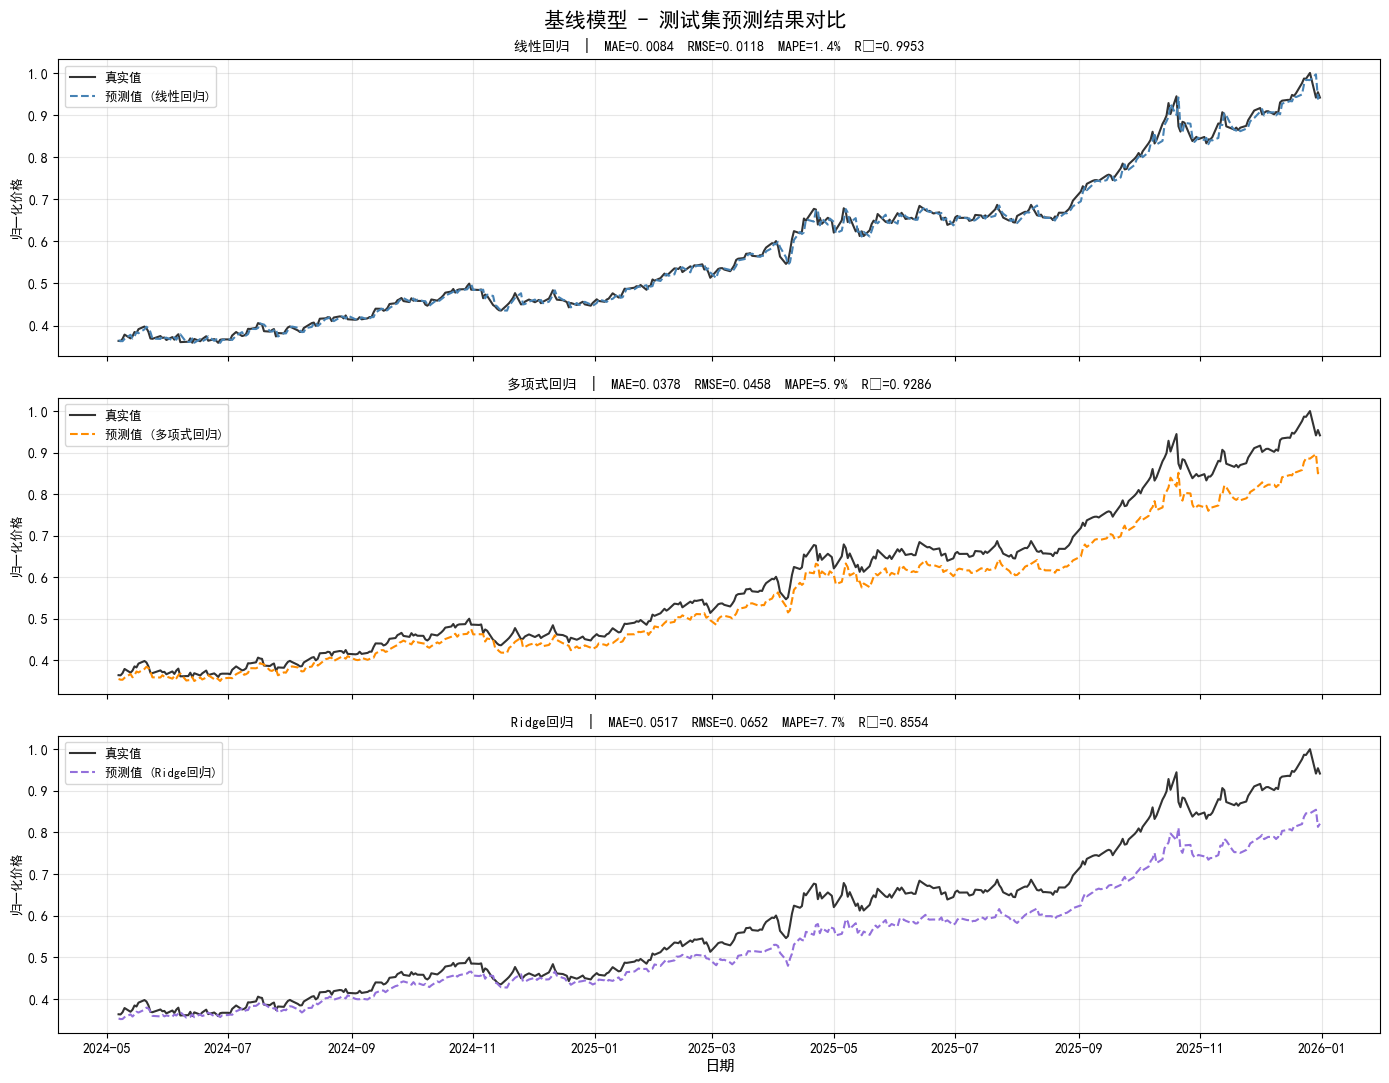

基线模型预测图已保存


In [16]:
# 基线模型预测结果可视化

test_dates = test_df.index

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle('基线模型 - 测试集预测结果对比', fontsize=15, fontweight='bold')

colors = {'线性回归': 'steelblue', '多项式回归': 'darkorange', 'Ridge回归': 'mediumpurple'}

for ax, (model_name, y_pred) in zip(axes, all_preds.items()):
    m = all_results[model_name]
    ax.plot(test_dates, y_test, color='black', linewidth=1.5,
            label='真实值', alpha=0.8)
    ax.plot(test_dates, y_pred, color=colors[model_name],
            linewidth=1.5, linestyle='--', label=f'预测值 ({model_name})')
    ax.set_ylabel('归一化价格', fontsize=9)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    # 在右上角显示评估指标
    info = f"MAE={m['mae']:.4f}  RMSE={m['rmse']:.4f}  MAPE={m['mape']:.1f}%  R²={m['r2']:.4f}"
    ax.set_title(f'{model_name}  |  {info}', fontsize=10)

axes[-1].set_xlabel('日期', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'baseline_predictions.png'), dpi=150, bbox_inches='tight')
plt.show()
print("基线模型预测图已保存")

## 第六部分：深度学习

In [17]:
# TODO

## 第七部分：模型对比